# **Project 2: Model Comparison (Phase 1, Pulsar Classification)**

David Almona \
DSC 340: Applied Machine Learning \
Spring 2026

---

**Dataset:** HTRU2 Pulsar (17,898 rows, 8 features, binary classification)

**Metric:** F1 score (on the pulsar
class)

**Goal:** Using `Pipeline`, run and compare five models on the dataset. Then make a decision on which to deploy and explain why.



**Sections:**

01. Import Libraries
02. Data Loading and Brief EDA
03. Train/Test Split
04. Five-Model Pipeline
05. Results Table
06. Verdict
07. References and Acknowledgments

---
## 00. Install packages (if needed)

In [2]:
# %pip install numpy pandas matplotlib seaborn scikit-learn

## 01. Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

## 02. Data loading and brief EDA

Radio telescopes generate candidate signals that might be pulsars (rotating neutron stars) or noise. Each row has 8 statistical features computed from the signal’s integrated profile and DM-SNR curve.

The target is binary: 1 = pulsar, 0 = noise. The class split is roughly 91/9, 

In [4]:
# Load dataset
df = pd.read_csv('pulsar.csv')
print(f'Shape: {df.shape}')
print()
df.head()

Shape: (17898, 9)



,profile_mean,profile_std,profile_kurtosis,profile_skewness,dmsnr_mean,dmsnr_std,dmsnr_kurtosis,dmsnr_skewness,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [5]:
# Check dataset dimensions and data types
print(f"Shape: {df.shape}")
print()
print(f"Data types:\n{df.dtypes}")

Shape: (17898, 9)

Data types:
profile_mean        float64
profile_std         float64
profile_kurtosis    float64
profile_skewness    float64
dmsnr_mean          float64
dmsnr_std           float64
dmsnr_kurtosis      float64
dmsnr_skewness      float64
target                int64
dtype: object


In [6]:
# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")
print()
print(f"Missing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Missing values: 0

Missing values per column:
Series([], dtype: int64)


In [7]:
df.describe().round(2)

,profile_mean,profile_std,profile_kurtosis,profile_skewness,dmsnr_mean,dmsnr_std,dmsnr_kurtosis,dmsnr_skewness,target
count,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00
mean,111.08,46.55,0.48,1.77,12.61,26.33,8.30,104.86,0.09
std,25.65,6.84,1.06,6.17,29.47,19.47,4.51,106.51,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.96,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,83.06,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.43,10.70,139.31,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00


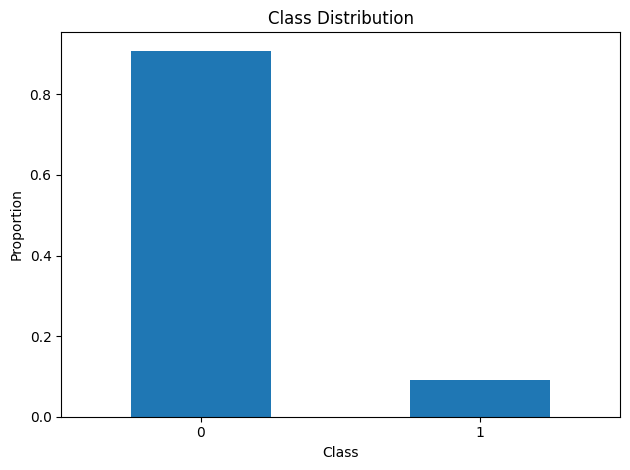

In [11]:
# class distribution
target_col = df.columns[-1]
class_counts = df[target_col].value_counts(normalize = True)

# plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.xticks(rotation = 0) 
plt.tight_layout()
plt.show()

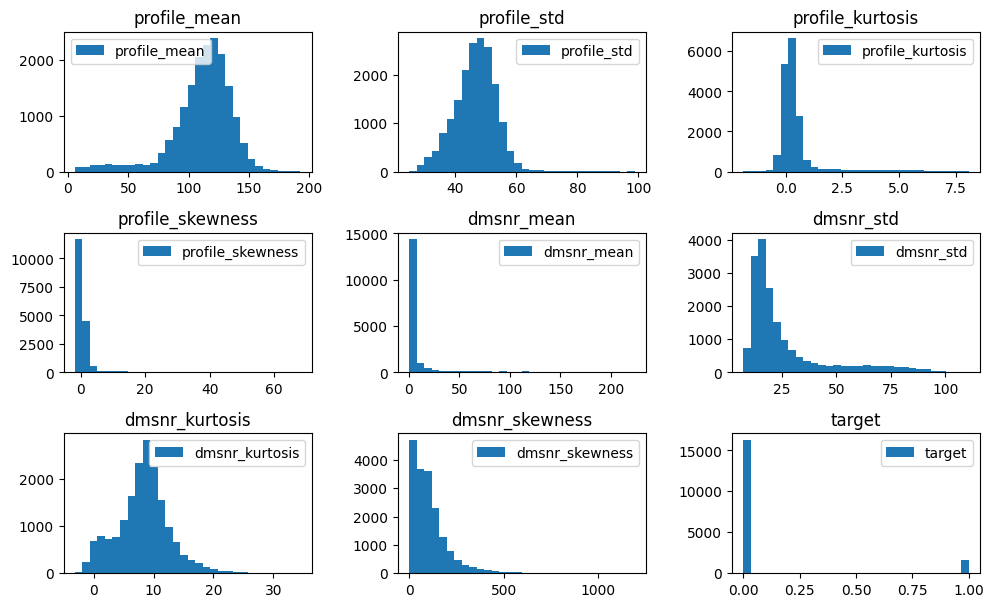

In [ ]:
plt.figure(figsize=(10,20))
try:
    for i, col in enumerate(df.columns.to_list()):
        plt.subplot(10, 3, i + 1)
        plt.hist(df[col], label = col, bins = 30)
        plt.legend()
        plt.title(col)
        plt.tight_layout()
except Exception as e:
    print(col,e)

# reference: https://stackoverflow.com/questions/61030348/how-to-plot-distribution-of-30-features-in-one-plot-and-differentiating-by-label

## 03. Train/test split
80/20 stratified split, `random_state=42`.


In [ ]:
y = df["target"]
X = df.drop(columns="target")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

print(f'Training: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')
print(f'Features: {X_train.shape[1]}')

Training: 14,318  Test: 3,580
Features: 8


## 04. Five-model pipeline

Define a `Pipeline` (scaler + model) and a hyperparameter grid for each of the five classifiers. 

Run `GridSearchCV` with `scoring='f1'` and 5-fold `StratifiedKFold`.

Report the best CV F1 for each model.

In [ ]:
# define Pipeline and hyperparamter grid for each classifier
# log reg, knn, random forest, svm-rbf, svm-linear

pipelines = {
    'Logistic Regression' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter = 2000, random_state = 42))
        ]),
        'params' : {
            'clf__C' : [0.01, 0.1, 1, 10, 100]
        }
    },
    'KNN' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'params' : {
            'clf__n_neighbors' : [3, 5, 11, 21, 41],
            'clf__weights' : ['uniform', 'distance']
        }
    },
    'Random Forest' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(random_state = 42))
        ]),
        'params' : {
            'clf__n_estimators' : [100, 300],
            'clf__max_depth' : ['None', 10, 20],
            'clf__max_features' : ['sqrt', 'log2']
        }
    },
    'SVM (RBF)' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel = 'rbf', random_state = 42))
        ]),
        'params' : {
            'clf__C' : [0.1, 1, 10, 100],
            'clf__gamma' : ['scale', 'auto', 0.01, 0.1]
        }
    },
    'SVM (Linear)' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel = 'linear', random_state = 42))
        ]),
        'params' : {
            'clf__C' : [0.001, 0.01, 0.1, 1, 10]
        }
    }
}

In [ ]:
# Run all five grid searches
results = []

for name, spec in pipelines.items():
    print(f'Running {name}...', end=' ')
    gs = GridSearchCV(
        spec['pipe'], spec['params'], cv=cv,
        scoring='f1', n_jobs=-1, refit=True
    )
    start = time.time()
    gs.fit(X_train, y_train)
    elapsed = time.time() - start
    
    results.append({
        'Model': name,
        'Best CV F1': gs.best_score_,
        'Best Params': gs.best_params_,
        'Fit Time (s)': round(elapsed, 1),
        'grid_search': gs  # keep the fitted object for later
    })
    print(f'F1={gs.best_score_:.4f}  ({elapsed:.1f}s)')

print()
print('Done.')

Running Logistic Regression... F1=0.8776  (7.4s)
Running KNN... F1=0.8722  (1.7s)
Running Random Forest... F1=0.8884  (104.4s)
Running SVM (RBF)... F1=0.8814  (34.6s)
Running SVM (Linear)... F1=0.8784  (8.9s)

Done.


## 05. Results table

A summary table showing, for each model: best CV F1, best hyperparameters, and training time.


In [ ]:
# Results table (without the grid_search objects)
results_df = pd.DataFrame(results).drop(columns='grid_search')
results_df = results_df.sort_values('Best CV F1', ascending=False)
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = 'Rank'
results_df

,Model,Best CV F1,Best Params,Fit Time (s)
Rank,,,,
1,Random Forest,0.888384,"{'clf__max_depth': 20, 'clf__max_features': 'l...",104.4
2,SVM (RBF),0.881410,"{'clf__C': 100, 'clf__gamma': 0.1}",34.6
3,SVM (Linear),0.878387,{'clf__C': 10},8.9
4,Logistic Regression,0.877605,{'clf__C': 100},7.4
5,KNN,0.872209,"{'clf__n_neighbors': 11, 'clf__weights': 'dist...",1.7


## 06. Verdict

The model I would select for deployment is **Logistic Regression**. Although the models achieved comparable F1 scores on the pulsar classification task, Logistic Regression is the simplest and most interpretable of the five, which aligns with the principle of preferring parsimony when performance differences are marginal. It is also substantially faster to train than the ensemble and kernel-based alternatives, making it the most practical choice for a production setting.

## 07. References and acknowledgements

Shreya, S. (2021, May 22). *Re: How to plot distribution of 30 features in one plot and differentiating by label in python* [Online forum post]. Stack Overflow. https://stackoverflow.com/questions/61030348/how-to-plot-distribution-of-30-features-in-one-plot-and-differentiating-by-label

Allen, T. (2026). *model-selection-demo* [Jupyter Notebook]. Centre College.

GitHub. (2026). *GitHub Copilot* [AI-powered coding assistant]. GitHub, Inc. https://github.com/features/copilot